In [2]:
# Task 1: Linear Regression using California Housing Dataset

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1: Load Dataset
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("First 5 Rows:")
print(df.head())

# Step 2: Features and Target
X = df.drop('Price', axis=1)
y = df['Price']

# Step 3: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Predict
y_pred = model.predict(X_test)

# Step 6: Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

# Display Actual vs Predicted
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:")
print(results.head(10))

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Model Evaluation
----------------
Mean Absolute Error (MAE): 0.5332001304956557
Mean Squared Error (MSE): 0.5558915986952442
Root Mean Squared Error (RMSE): 0.7455813830127763
R2 Score: 0.575787706032451

Actual vs Predicted Prices:
   Actual Price  Predicted Price
0       0.47700         0.719123
1       0.45800         1.764017
2       5.00001         2.709659
3       2.18600         2.83892

In [4]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Boston Housing Dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)
X = boston.data
y = boston.target.astype(float)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (required for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Support Vector Regression
# -----------------------------
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

# -----------------------------
# Decision Tree Regression
# -----------------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance")
    print("-" * 30)
    print("Mean Absolute Error :", mean_absolute_error(y_true, y_pred))
    print("Mean Squared Error  :", mean_squared_error(y_true, y_pred))
    print("Root Mean Squared Error :", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score :", r2_score(y_true, y_pred))

# Evaluate Models
evaluate_model("Support Vector Regression", y_test, y_pred_svr)
evaluate_model("Decision Tree Regression", y_test, y_pred_dt)


Support Vector Regression Performance
------------------------------
Mean Absolute Error : 2.7317161761558397
Mean Squared Error  : 25.66853967839604
Root Mean Squared Error : 5.0664129005042655
R2 Score : 0.6499766059760035

Decision Tree Regression Performance
------------------------------
Mean Absolute Error : 2.394117647058824
Mean Squared Error  : 10.416078431372549
Root Mean Squared Error : 3.2273949915330395
R2 Score : 0.8579634380978161


Model Evaluation Metrics
------------------------
Mean Absolute Error (MAE): 0.5332001304956989
Mean Squared Error (MSE): 0.5558915986952425
Root Mean Squared Error (RMSE): 0.7455813830127751
R² Score: 0.5757877060324521


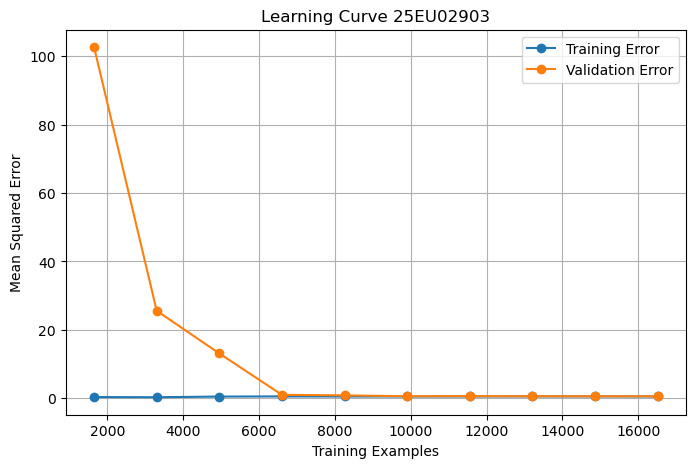

In [7]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Generate Learning Curve
train_sizes, train_scores, validation_scores = learning_curve(
    model,
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='neg_mean_squared_error'
)

# Convert negative MSE to positive
train_scores_mean = -train_scores.mean(axis=1)
validation_scores_mean = -validation_scores.mean(axis=1)

# Plot Learning Curve
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training Error")
plt.plot(train_sizes, validation_scores_mean, 'o-', label="Validation Error")

plt.title("Learning Curve 25EU02903")
plt.xlabel("Training Examples")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.show()